# What did radar and satellites show around a reported tornado?

Take one Oklahoma tornado report, find the radar volume and the infrared
satellite scene whose starts lie nearest its time, and show both around the
reported position. The worked case is Storm Events report **1184052**, an EF1
tornado in Oklahoma County on the evening of 6 May 2024, with the KTLX radar
and GOES-16 channel 13. The manifest records the three inputs selected during
discovery; the cells below repeat the selection and check that those choices
still match the locked inputs.

The answer is context at nearby times, not a detection: nearest scan starts do
not make simultaneous measurements, and neither panel shows a tornado.

It needs `usdata[pandas,radar,netcdf]` and matplotlib; `pyproj` arrives with the
radar extra. The three files total about 36 MB, the empty-cache restore at the
end downloads them once more, and decoding needs several hundred MB of memory.
A run takes well under a minute.

In [1]:
import gc
import tempfile
import time
from datetime import UTC, datetime, timedelta, timezone
from importlib.metadata import version
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pyproj import CRS, Geod, Transformer

from usdata import build_query, cite_lockfile, get, pull, select_by_time, verify
from usdata.providers import load_adapter
from usdata.readers import RadarDecodeError

# One figure style for every usdata notebook, so previews look alike.
plt.rcParams.update(
    {
        "figure.figsize": (8, 4.5),
        "figure.dpi": 120,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "font.size": 10,
    }
)
manifest = Path("dataset.yaml")
print("Executed (UTC):", datetime.now(UTC).isoformat(timespec="seconds"))
print(
    "; ".join(
        f"{name} {version(name)}" for name in ("usdata", "pandas", "xradar", "xarray", "pyproj")
    )
)

Executed (UTC): 2026-09-24T06:08:03+00:00
usdata 0.26.0; pandas 3.0.6; xradar 0.12.0; xarray 2026.7.0; pyproj 3.8.0


## Data

| Dataset | What it pins | Why |
|---|---|---|
| [Storm Events](https://usdata.dev/datasets/noaa/storm-events/) | The whole 2024 annual details archive, selected by a 6 May 2024 window | The report's time and position |
| [NEXRAD Level II](https://usdata.dev/datasets/noaa/nexrad-level2/) | One KTLX volume, at the scan start found during discovery | Reflectivity near the report time |
| [GOES ABI](https://usdata.dev/datasets/noaa/goes-abi/) | One GOES-16 CONUS channel 13 scene, at its discovered scan start | Cloud-top brightness temperature near the report time |

Storm Events bulk access returns a complete annual archive even for a one-day
query. NCEI can revise older years; the lock pins the creation-date filename and
checksum. The radar and GOES bounds in the manifest equal the discovered scan
starts. On later runs, `pull` restores the lock without repeating provider
discovery.

In [2]:
print(manifest.read_text().strip())

started = time.perf_counter()
result = pull(manifest)
assert len(result.fetched) == 3
items = {item.asset.dataset_id: item for item in result.fetched}
assert len(items) == 3
print("\nPull seconds:", round(time.perf_counter() - started, 2))
print("Total source bytes:", sum(item.provenance.size for item in result.fetched))
pd.DataFrame(
    {
        "dataset": item.asset.dataset_id,
        "asset": item.asset.id,
        "bytes": item.provenance.size,
        "retrieved_utc": item.provenance.retrieved_at.isoformat(timespec="seconds"),
        "checksum": item.provenance.checksum[:23] + "...",
    }
    for item in result.fetched
)

name: oklahoma-event-1184052-context
sources:
- dataset: noaa:storm-events
  start: '2024-05-06'
  end: '2024-05-06'
- dataset: noaa:nexrad-level2
  start: '2024-05-07T04:40:53+00:00'
  end: '2024-05-07T04:40:53+00:00'
  params:
    site: KTLX
- dataset: noaa:goes-abi
  start: '2024-05-07T04:41:17.300000+00:00'
  end: '2024-05-07T04:41:17.300000+00:00'
  params:
    satellite: 16
    channel: 13



Pull seconds: 3.46
Total source bytes: 36252915


,dataset,asset,bytes,retrieved_utc,checksum
0,noaa:storm-events,StormEvents_details-ftp_v1.0_d2024_c20260728.c...,12693243,2026-09-24T06:08:04+00:00,sha256:2070b83eccab041b...
1,noaa:nexrad-level2,KTLX20240507_044053_V06,19826021,2026-09-24T06:08:05+00:00,sha256:0599ac838bd27cb3...
2,noaa:goes-abi,OR_ABI-L2-CMIPC-M6C13_G16_s20241280441173_e202...,3733651,2026-09-24T06:08:06+00:00,sha256:587a0decd9bac14a...


## Read the report's time convention explicitly

[NCEI event 1184052](https://www.ncei.noaa.gov/stormevents/eventdetails.jsp?id=1184052)
is an EF1 tornado report beginning in Oklahoma County at 22:39 on May 6, 2024.
The [bulk-format reference](https://www.ncei.noaa.gov/pub/data/swdi/stormevents/csvfiles/Storm-Data-Bulk-csv-Format.pdf)
identifies local standard time and the `CZ_TIMEZONE` offset. This row says
`CST-6`: use **fixed UTC−6**, giving 04:39 UTC on May 7. Applying a regional
zone's daylight-saving offset would shift this case by an hour. The cell rejects
an unreviewed timezone label rather than guessing, and checks its conversion
against the `BEGIN_UTC` column the reader derives. Coordinates mark the reported
path start; a report record is not necessarily an independent storm.

In [3]:
columns = [
    "EVENT_ID",
    "EVENT_TYPE",
    "STATE",
    "CZ_NAME",
    "BEGIN_DATE_TIME",
    "END_DATE_TIME",
    "CZ_TIMEZONE",
    "BEGIN_LAT",
    "BEGIN_LON",
    "TOR_F_SCALE",
    "SOURCE",
]
frame = items["noaa:storm-events"].open_csv(usecols=columns)
rows = frame.loc[frame.EVENT_ID.eq("1184052")]
assert len(rows) == 1
report = rows.iloc[0]
if report.CZ_TIMEZONE != "CST-6":
    raise ValueError(f"Review source timezone before matching: {report.CZ_TIMEZONE}")
local_time = datetime.strptime(report.BEGIN_DATE_TIME, "%d-%b-%y %H:%M:%S")
event_time = local_time.replace(tzinfo=timezone(timedelta(hours=-6))).astimezone(UTC)
assert event_time == report.BEGIN_UTC.to_pydatetime(), "the reader derived a different UTC time"
lat, lon = float(report.BEGIN_LAT), float(report.BEGIN_LON)
assert np.isfinite([lat, lon]).all() and -90 <= lat <= 90 and -180 <= lon <= 180
for key, value in report.items():
    print(f"{key:16s} {value}")
print("\nReport start UTC:", event_time.isoformat())
del frame, rows
gc.collect();

EVENT_ID         1184052
STATE            OKLAHOMA
EVENT_TYPE       Tornado
CZ_NAME          OKLAHOMA
BEGIN_DATE_TIME  06-MAY-24 22:39:00
CZ_TIMEZONE      CST-6
END_DATE_TIME    06-MAY-24 22:42:00
SOURCE           NWS Storm Survey
TOR_F_SCALE      EF1
BEGIN_LAT        35.378
BEGIN_LON        -97.543
BEGIN_UTC        2024-05-07 04:39:00+00:00
END_UTC          2024-05-07 04:42:00+00:00

Report start UTC: 2024-05-07T04:39:00+00:00


## Check the nearest listed scan starts within ±5 minutes

KTLX and GOES-16 C13 are explicit choices for this historical case. Use
`select_by_time` to rank each provider's candidates by absolute start-time
difference, breaking ties by asset ID. Require a match within 300 seconds and
compare the winner with the manifest's fetched asset. The result records the
policy, signed offset, and candidate counts; missing or naive start times raise
instead of being skipped. If this fails, investigate changed source listings or
report revisions before editing the manifest and deliberately resolving a new
lock. The time tolerance is an analysis choice, not an SDK default. This cell is
deliberately live; it is not needed merely to restore an existing analysis.

This matches **scan starts**, not the exact ray or satellite pixel acquisition
time. Radar volumes and GOES scans span time; nearest starts do not imply
simultaneous measurements or prove a reported tornado's presence. The table also
compares `at_or_before`: this selects a prior **start**, which can still belong
to a scan containing observations acquired after the report time.

In [4]:
matches = []
for dataset_id, params in [
    ("noaa:nexrad-level2", {"site": "KTLX"}),
    ("noaa:goes-abi", {"satellite": 16, "channel": 13}),
]:
    query = build_query(
        start=event_time - timedelta(minutes=5), end=event_time + timedelta(minutes=5), **params
    )
    with load_adapter(get(dataset_id)) as provider:
        candidates = provider.list_assets(query)
    selection = select_by_time(
        candidates, target=event_time, tolerance=timedelta(minutes=5), direction="nearest"
    )
    prior = select_by_time(
        candidates, target=event_time, tolerance=timedelta(minutes=5), direction="at_or_before"
    )
    assert selection.asset is not None, f"No scan start within tolerance: {dataset_id}"
    nearest = selection.asset
    delta = selection.offset_seconds
    assert nearest.id == items[dataset_id].asset.id, "Revisit the manifest selection"
    matches.append(
        {
            "dataset": dataset_id,
            "candidates": selection.candidate_count,
            "eligible": selection.eligible_count,
            "scan_start_utc": nearest.time.start.isoformat(),
            "scan_end_utc": nearest.time.end.isoformat(),
            "start_offset_seconds": delta,
            "prior_start_offset_seconds": prior.offset_seconds,
        }
    )
pd.DataFrame(matches)

,dataset,candidates,eligible,scan_start_utc,scan_end_utc,start_offset_seconds,prior_start_offset_seconds
0,noaa:nexrad-level2,2,2,2024-05-07T04:40:53+00:00,2024-05-07T04:40:53+00:00,113.0,-273.0
1,noaa:goes-abi,2,2,2024-05-07T04:41:17.300000+00:00,2024-05-07T04:43:55.700000+00:00,137.3,-162.7


## Open the first radar sweep and inspect the full-volume limitation

This archive has an interior sweep without an end marker. With xradar 0.12,
later coordinate entries shift, so full-volume decoding is unsafe; even equal
ray counts can hide incorrect coordinate pairing. The SDK checks record alignment
and raises `RadarDecodeError`. The first sweep is unaffected and opens through
`item.open_nexrad(sweep=0)` with normal flag masking and provenance. No direct decoder
fallback or silent sweep dropping is used.

The full-volume probe below records the guard result; if a future backend repairs
the file, it reports that success instead. It does not suppress unrelated errors.
See [ADR 0011](https://docs.usdata.dev/adr/0011-radar-sweep-alignment/).

In [5]:
radar_item = items["noaa:nexrad-level2"]
try:
    full_volume = radar_item.open()
except RadarDecodeError as error:
    print("Full-volume limitation:", error)
else:
    print("This decoder passed full-volume alignment checks:", full_volume.groups)
    del full_volume
radar = radar_item.open_nexrad(sweep=0)
sweep = radar["sweep_0"].to_dataset()
assert radar.attrs["usdata"]["sweeps"] == ["sweep_0"]
assert radar.attrs["usdata"]["provenance"]["checksum"] == radar_item.provenance.checksum
print("Sweep dimensions:", dict(sweep.sizes))
print("Elevation degrees:", float(sweep.sweep_fixed_angle))
print("Ray time range:", str(sweep.time.min().values), "to", str(sweep.time.max().values))
nearby = sweep.DBZH.sel(range=slice(None, 100_000))
assert nearby.attrs["units"] == "dBZ"
bearing, _, distance = Geod(ellps="WGS84").inv(
    float(radar.longitude), float(radar.latitude), lon, lat
)
print("Report ground distance from KTLX (km):", round(distance / 1000, 2))

Full-volume limitation: cannot safely decode sweep 14: NEXRAD moment and coordinate records do not agree; select an unaffected sweep explicitly with open(sweep=...) or use another decoder. No sweeps were silently dropped.


Sweep dimensions: {'azimuth': 720, 'range': 1832}
Elevation degrees: 0.4833984375
Ray time range: 2024-05-07T04:40:53.536000000 to 2024-05-07T04:41:09.636999936
Report ground distance from KTLX (km): 24.61


## Locate the report in the GOES fixed grid

Build the geostationary CRS from the source CF projection attributes using
[pyproj](https://pyproj4.github.io/pyproj/stable/build_crs_cf.html), transform the
reported longitude/latitude to projected meters, then divide by perspective
height to recover native scan angles. See NOAA's
[GOES projection guide](https://www.star.nesdis.noaa.gov/atmospheric-composition-training/satellite_data_goes_imager_projection.php).
Check domain coverage before selecting a pixel. Keep only DQF=0 pixels in the
plot; this is a source quality flag, not complete science quality control.

The window below is ±120 km in projection-plane coordinates, **not** a constant
ground-distance radius. The star is the ground projection of the report location;
it is not corrected for cloud-height parallax. Brightness temperature is in K,
and is not surface air temperature or a tornado detector.

In [6]:
scene = items["noaa:goes-abi"].open()
projection = scene.goes_imager_projection.attrs
transform = Transformer.from_crs("EPSG:4326", CRS.from_cf(projection), always_xy=True)
px, py = transform.transform(lon, lat)
height = projection["perspective_point_height"]
sx, sy = px / height, py / height
assert np.isfinite([sx, sy]).all()
assert float(scene.x.min()) <= sx <= float(scene.x.max())
assert float(scene.y.min()) <= sy <= float(scene.y.max())
ix = int(np.abs(scene.x.values - sx).argmin())
iy = int(np.abs(scene.y.values - sy).argmin())
point = scene.isel(x=ix, y=iy)
print(
    "Ground-projected nearest pixel:",
    {
        "x": ix,
        "y": iy,
        "DQF": int(point.DQF),
        "accepted_CMI_K": round(float(point.CMI), 1) if int(point.DQF) == 0 else None,
    },
)
half_window = 120_000 / height
roi = scene.isel(
    x=np.flatnonzero(abs(scene.x.values - sx) < half_window),
    y=np.flatnonzero(abs(scene.y.values - sy) < half_window),
)
brightness = roi.CMI.where(roi.DQF == 0)
assert brightness.attrs["units"] == "K" and int(brightness.count()) > 0
print("Crop dimensions:", dict(brightness.sizes), "DQF=0 pixels:", int(brightness.count()))
print(f"Coldest accepted pixel in the crop: {float(brightness.min()):.1f} K")

Ground-projected nearest pixel: {'x': 861, 'y': 540, 'DQF': 0, 'accepted_CMI_K': 209.9}
Crop dimensions: {'y': 120, 'x': 120} DQF=0 pixels: 14400
Coldest accepted pixel in the crop: 198.7 K


## Radar and infrared around the report

Left, the first KTLX sweep out to 100 km, in the radar's own polar coordinates.
Right, the GOES-16 channel 13 crop in the satellite's scan-angle coordinates.
The stars mark the reported start of the tornado path.

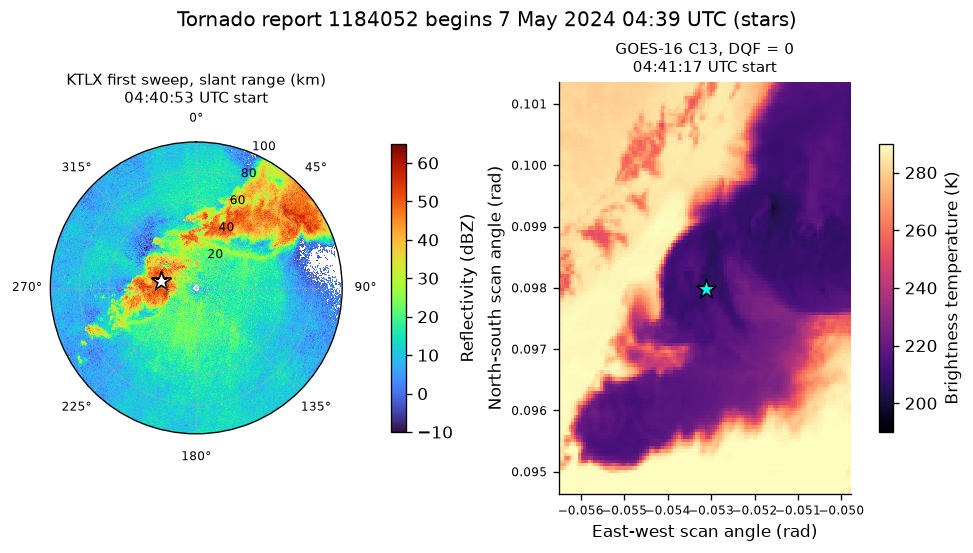

In [7]:
fig = plt.figure(layout="constrained")
ax_radar = fig.add_subplot(121, projection="polar")
ax_goes = fig.add_subplot(122)
mesh = ax_radar.pcolormesh(
    np.deg2rad(nearby.azimuth.values),
    nearby.range.values / 1000,
    nearby.values.T,
    cmap="turbo",
    shading="auto",
    vmin=-10,
    vmax=65,
)
ax_radar.scatter(
    np.deg2rad(bearing), distance / 1000, marker="*", s=150, c="white", edgecolors="black"
)
ax_radar.set_theta_zero_location("N")
ax_radar.set_theta_direction(-1)
ax_radar.set_ylim(0, 100)
ax_radar.tick_params(labelsize=7)
ax_radar.set_title("KTLX first sweep, slant range (km)\n04:40:53 UTC start", fontsize=9)
fig.colorbar(mesh, ax=ax_radar, label="Reflectivity (dBZ)", shrink=0.7)
mesh = ax_goes.pcolormesh(
    brightness.x, brightness.y, brightness, cmap="magma", shading="auto", vmin=190, vmax=290
)
ax_goes.scatter(sx, sy, marker="*", s=150, c="cyan", edgecolors="black")
ax_goes.grid(False)
ax_goes.tick_params(labelsize=7)
ax_goes.set(
    xlabel="East-west scan angle (rad)",
    ylabel="North-south scan angle (rad)",
)
ax_goes.set_title("GOES-16 C13, DQF = 0\n04:41:17 UTC start", fontsize=9)
fig.colorbar(mesh, ax=ax_goes, label="Brightness temperature (K)", shrink=0.7)
fig.suptitle("Tornado report 1184052 begins 7 May 2024 04:39 UTC (stars)")
plt.show()
plt.close(fig)
del radar, sweep, nearby, scene, roi, brightness, point
gc.collect();

The report sits inside a band of reflectivity above 50 dBZ, 25 km west of the
radar, and under the cold anvil of the storm on the infrared image, where the
nearest accepted pixel is about 210 K.

Radar radial range is slant distance; the plotted star uses approximate ground
distance and bearing, not a beam-height calculation. These panels supply storm
context at nearby times. They do not establish tornadogenesis, causation, or
exact collocation. A stronger study needs multiple times, radar beam geometry,
cloud-parallax treatment, additional moments and quality control, and
independent report review. Temporal ranking uses the shared `select_by_time`
helper; report interpretation, source-time conversion, site choice, and
projection choices remain explicit in this notebook.

## Pin and cite

`verify` checks every cached file against the lockfile's checksums, and the
citations below are what a methods section needs; `usdata cite dataset.yaml`
prints the same.

In [8]:
assert verify(manifest) == []
for citation in cite_lockfile(manifest):
    print(citation.as_text())
    print()

noaa:storm-events
  NOAA National Centers for Environmental Information, Storm Events Database, accessed via usdata
  homepage: https://www.ncei.noaa.gov/access/storm-events-database/
  license: US Government Work (public domain)
  terms: https://www.ncei.noaa.gov/metadata/geoportal/rest/metadata/item/gov.noaa.ncdc:C00510/html
  retrieved: 2026-09-24; 1 checksummed asset (12,693,243 bytes) pinned by usdata 0.26.0
  sources: 1

noaa:nexrad-level2
  NEXRAD on AWS was accessed on 2026-09-24 from https://registry.opendata.aws/noaa-nexrad
  homepage: https://registry.opendata.aws/noaa-nexrad/
  license: US Government Work (public domain)
  terms: https://www.noaa.gov/information-technology/open-data-dissemination
  retrieved: 2026-09-24; 1 checksummed asset (19,826,021 bytes) pinned by usdata 0.26.0
  sources: 2

noaa:goes-abi
  NOAA Geostationary Operational Environmental Satellites (GOES) 16, 17, 18 & 19 was accessed on 2026-09-24 from https://registry.opendata.aws/noaa-goes
  homepage: h

A second pull should use verified cached bytes, and a separate temporary empty
cache must restore all three locked assets without provider re-resolution. This
checks the reproducibility mechanism today; upstream can still remove old files,
so keep the manifest, the lockfile, and the cached bytes together.

In [9]:
again = pull(manifest)
assert again.from_lockfile and all(item.from_cache for item in again.fetched)
assert verify(manifest) == []
with tempfile.TemporaryDirectory(prefix="usdata-event-restore-") as directory:
    started = time.perf_counter()
    restored = pull(manifest, root=Path(directory))
    assert restored.from_lockfile and not any(item.from_cache for item in restored.fetched)
    assert verify(manifest, root=Path(directory)) == []
    assert [item.provenance.checksum for item in restored.fetched] == [
        item.provenance.checksum for item in result.fetched
    ]
    print("Empty-cache restoration seconds:", round(time.perf_counter() - started, 2))
print("All three inputs verified; cached and empty-cache locked restoration passed.")

Empty-cache restoration seconds: 2.92
All three inputs verified; cached and empty-cache locked restoration passed.


## What was awkward

- This KTLX volume cannot be opened whole: an interior sweep has no end marker,
  so `open()` raises `RadarDecodeError` and the notebook has to name
  `sweep=0` to get anything.
- A NEXRAD asset's time range is a point: `scan_end_utc` equals the scan start,
  although the volume takes minutes to collect, so the listing cannot say which
  volume contains a given instant.
- Pinning one scan means copying its discovered start into the manifest to the
  tenth of a second (`04:41:17.300000`); there is no way to say "the scan nearest
  this time" in the manifest itself.
- Checking the lock against today's listings means dropping below the manifest
  to `load_adapter`, `build_query`, and `list_assets`.
- Placing a longitude and latitude on the GOES fixed grid takes a CRS built from
  the file's CF attributes and a division by the perspective height, all by hand.
- The reader derives `BEGIN_UTC` only when `END_DATE_TIME` is also among the
  columns read, so a narrower `usecols` silently loses it.